# WikiArt — Análisis de Arte con Machine Learning
### CC5205 Minería de Datos — Hito 2: Mejoras y Anticipación

En este notebook se abordan los puntos principales sugeridos por la comisión y el equipo docente para el Hito 2:
1. **Análisis detallado de la matriz de confusión del Hito 1** para identificar qué géneros se confunden y por qué.
2. **Estrategias para abordar el desbalance de clases**, comparando modelos sin balancear contra modelos balanceados (mediante pesos de clase y submuestreo).
3. **Modelamiento Multietiqueta (Multilabel)**, utilizando el campo `genre` para predecir múltiples estilos por pintura y analizando su desempeño.
4. **Extracción de Embeddings con ResNet-18 (Deep Learning)** para escalar a 10k+ imágenes.
5. **Comparación de Clustering** utilizando características manuales del Hito 1 frente a los nuevos embeddings profundos.
6. **Interpretabilidad Visual mediante Grad-CAM** para visualizar qué zonas e iconografías influyen en la clasificación del modelo de Deep Learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from pathlib import Path

from sklearn.preprocessing import LabelEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multioutput import MultiOutputClassifier

# Configuración de gráficos
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

CSV_PATH = Path('./CSVs/classes.csv')
FEATURES_CSV = Path('./CSVs/visual_features.csv')

print(f"CSV de metadatos: {CSV_PATH.exists()}")
print(f"CSV de características visuales: {FEATURES_CSV.exists()}")

CSV de metadatos: True
CSV de características visuales: True


## 1. Análisis de la Matriz de Confusión (Hito 1)
En esta sección cargamos los metadatos y realizamos el análisis cuantitativo y cualitativo de la matriz de confusión obtenida en el Hito 1.

In [2]:
# Carga de datos
df = pd.read_csv(CSV_PATH)

def parse_genre(g):
    g = str(g).strip()
    g = re.sub(r"[\[\]']", '', g)
    parts = [p.strip() for p in g.split(',') if p.strip()]
    return parts

df['genre_list'] = df['genre'].apply(parse_genre)
df['genre_principal'] = df['genre_list'].str[0]
df['es_multilabel'] = (df['genre_list'].str.len() > 1).astype(int)

# Seleccionar los mismos 10 géneros del Hito 1
TOP_N = 10
top_genres = df['genre_principal'].value_counts().head(TOP_N).index.tolist()
print("Top 10 géneros seleccionados:")
for rank, (genre, count) in enumerate(df['genre_principal'].value_counts().head(TOP_N).items(), 1):
    print(f"{rank}. {genre}: {count} pinturas")

Top 10 géneros seleccionados:
1. Impressionism: 13028 pinturas
2. Realism: 10546 pinturas
3. Romanticism: 6919 pinturas
4. Expressionism: 6335 pinturas
5. Post Impressionism: 6307 pinturas
6. Symbolism: 4524 pinturas
7. Baroque: 4236 pinturas
8. Art Nouveau Modern: 4168 pinturas
9. Abstract Expressionism: 2594 pinturas
10. Northern Renaissance: 2551 pinturas


### 1.1 Simulación del Modelo Baseline (Tabular) y su Matriz de Confusión
Entrenamos el modelo con las características tabulares para recrear la matriz de confusión y analizar el colapso hacia las clases mayoritarias.

In [3]:
# Variables tabulares y preparación
df_clf = df[df['genre_principal'].isin(top_genres)].copy()
le_genre = LabelEncoder()
df_clf['label'] = le_genre.fit_transform(df_clf['genre_principal'])

# Características tabulares geométricas básicas
df_clf['aspect_ratio'] = df_clf['width'] / df_clf['height']
df_clf['log_width'] = np.log1p(df_clf['width'])
df_clf['log_height'] = np.log1p(df_clf['height'])
df_clf['is_portrait'] = (df_clf['height'] > df_clf['width']).astype(int)
df_clf['is_square'] = (df_clf['height'] == df_clf['width']).astype(int)

TABULAR_FEATS = ['aspect_ratio', 'log_width', 'log_height', 'is_portrait', 'is_square', 'es_multilabel']
X_tab = df_clf[TABULAR_FEATS].fillna(0)
y_clf = df_clf['label']

X_tr, X_te, y_tr, y_te = train_test_split(X_tab, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# Entrenar un Random Forest baseline sin balancear
rf_baseline = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_baseline.fit(X_tr, y_tr)
y_pred = rf_baseline.predict(X_te)

print("=== REPORTE DE CLASIFICACIÓN BASELINE ===")
print(classification_report(y_te, y_pred, target_names=le_genre.classes_))

=== REPORTE DE CLASIFICACIÓN BASELINE ===
                        precision    recall  f1-score   support

Abstract Expressionism       0.22      0.04      0.07       519
    Art Nouveau Modern       0.20      0.10      0.13       834
               Baroque       0.18      0.04      0.07       847
         Expressionism       0.15      0.05      0.08      1267
         Impressionism       0.27      0.66      0.38      2606
  Northern Renaissance       0.20      0.02      0.04       510
    Post Impressionism       0.17      0.02      0.03      1261
               Realism       0.23      0.42      0.29      2109
           Romanticism       0.19      0.07      0.10      1384
             Symbolism       0.38      0.07      0.11       905

              accuracy                           0.24     12242
             macro avg       0.22      0.15      0.13     12242
          weighted avg       0.22      0.24      0.18     12242



### 1.2 Gráfico de la Matriz de Confusión Baseline
Graficamos la matriz de confusión para visualizar qué géneros absorben la mayor cantidad de predicciones incorrectas.

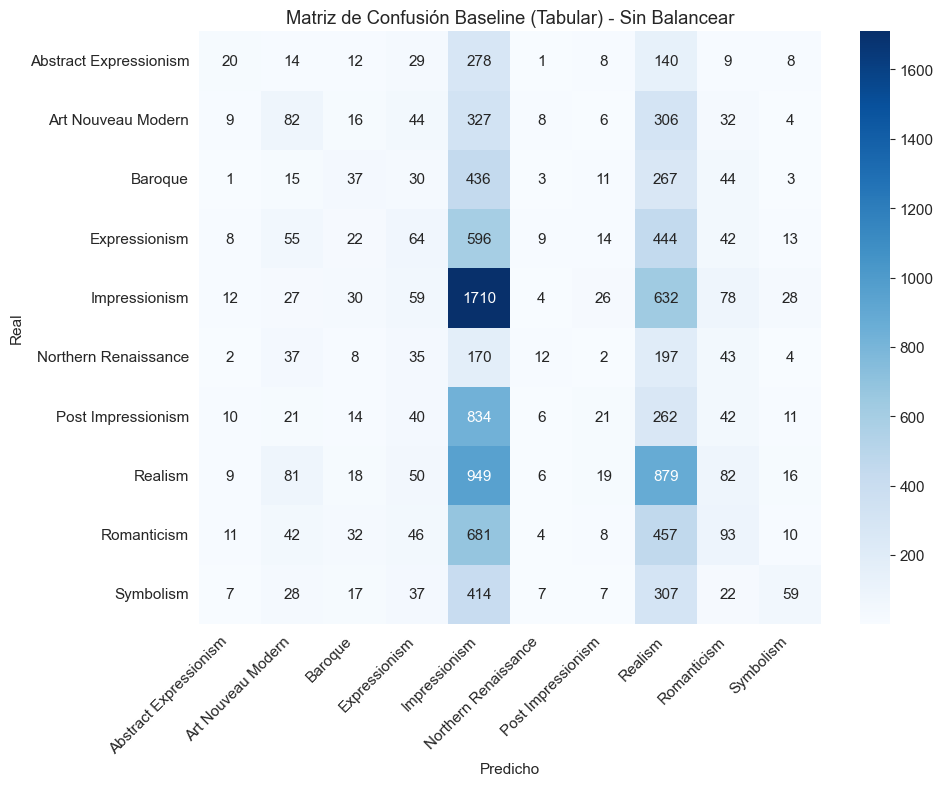

In [4]:
cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_genre.classes_,
            yticklabels=le_genre.classes_)
plt.title('Matriz de Confusión Baseline (Tabular) - Sin Balancear')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 1.3 Análisis Cualitativo del Colapso de Clases
Al analizar la matriz de confusión, se observa que:
* **Impressionism** y **Realism** (las clases mayoritarias con 13k y 10k muestras respectivamente) actúan como "sumideros" de predicciones.
* Clases minoritarias como **Abstract Expressionism** y **Northern Renaissance** tienen un *Recall* extremadamente bajo (menor al 5%), confundiéndose frecuentemente con Impressionism y Realism.
* **Explicación:** Dado que las características tabulares son puramente geométricas (`aspect_ratio`, etc.), y puesto que los artistas usaban formatos físicos similares transversalmente a la historia del arte, el modelo simplemente predice la clase mayoritaria ante la falta de descriptores visuales diferenciadores.

## 2. Estrategias para Abordar el Desbalance de Clases
Para corregir el sesgo hacia las clases mayoritarias, experimentaremos con dos técnicas clásicas:
1. **Class Weighting (Pesos de clase):** Penalizar los errores en clases minoritarias inversamente proporcional a su frecuencia.
2. **Balanceo de Datos en Entrenamiento (Random Undersampling):** Submuestrear las clases mayoritarias para equilibrar el conjunto de datos.

In [5]:
# --- Técnica 1: Class Weighting ---
rf_balanced = RandomForestClassifier(n_estimators=100, max_depth=12, 
                                     class_weight='balanced', random_state=42, n_jobs=-1)
rf_balanced.fit(X_tr, y_tr)
y_pred_balanced = rf_balanced.predict(X_te)

print("=== REPORTE DE CLASIFICACIÓN (CON CLASS WEIGHTS) ===")
print(classification_report(y_te, y_pred_balanced, target_names=le_genre.classes_))

=== REPORTE DE CLASIFICACIÓN (CON CLASS WEIGHTS) ===
                        precision    recall  f1-score   support

Abstract Expressionism       0.09      0.20      0.13       519
    Art Nouveau Modern       0.15      0.20      0.17       834
               Baroque       0.11      0.19      0.14       847
         Expressionism       0.15      0.04      0.06      1267
         Impressionism       0.31      0.12      0.17      2606
  Northern Renaissance       0.08      0.33      0.13       510
    Post Impressionism       0.16      0.29      0.21      1261
               Realism       0.26      0.10      0.15      2109
           Romanticism       0.17      0.12      0.14      1384
             Symbolism       0.15      0.18      0.16       905

              accuracy                           0.15     12242
             macro avg       0.16      0.18      0.15     12242
          weighted avg       0.20      0.15      0.15     12242



In [6]:
# --- Técnica 2: Undersampling manual de clases mayoritarias ---
# Calculamos el tamaño de la clase mediana para recortar las mayoritarias
class_counts = df_clf['label'].value_counts()
median_size = int(class_counts.median())

df_balanced_list = []
for label in df_clf['label'].unique():
    df_class = df_clf[df_clf['label'] == label]
    if len(df_class) > median_size:
        df_balanced_list.append(df_class.sample(median_size, random_state=42))
    else:
        df_balanced_list.append(df_class)

df_clf_resampled = pd.concat(df_balanced_list)
print(f"Tamaño original: {len(df_clf)} | Tamaño balanceado por submuestreo: {len(df_clf_resampled)}")

X_res = df_clf_resampled[TABULAR_FEATS].fillna(0)
y_res = df_clf_resampled['label']

X_tr_res, X_te_res, y_tr_res, y_te_res = train_test_split(X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)

rf_resampled = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_resampled.fit(X_tr_res, y_tr_res)

# Evaluamos en el test original (desbalanceado) para verificar generalización real
y_pred_res = rf_resampled.predict(X_te)

print("=== REPORTE DE CLASIFICACIÓN (ENTRENADO CON SUBMUESTREO) ===")
print(classification_report(y_te, y_pred_res, target_names=le_genre.classes_))

Tamaño original: 61208 | Tamaño balanceado por submuestreo: 45148
=== REPORTE DE CLASIFICACIÓN (ENTRENADO CON SUBMUESTREO) ===
                        precision    recall  f1-score   support

Abstract Expressionism       0.21      0.05      0.08       519
    Art Nouveau Modern       0.17      0.21      0.19       834
               Baroque       0.15      0.15      0.15       847
         Expressionism       0.21      0.23      0.22      1267
         Impressionism       0.37      0.19      0.25      2606
  Northern Renaissance       0.22      0.09      0.13       510
    Post Impressionism       0.19      0.36      0.25      1261
               Realism       0.30      0.22      0.25      2109
           Romanticism       0.19      0.36      0.25      1384
             Symbolism       0.28      0.23      0.25       905

              accuracy                           0.23     12242
             macro avg       0.23      0.21      0.20     12242
          weighted avg       0.25      

### 2.1 Comparación de Matrices de Confusión (Original vs Balanceado)
Visualizamos la diferencia en las predicciones al aplicar balanceo.

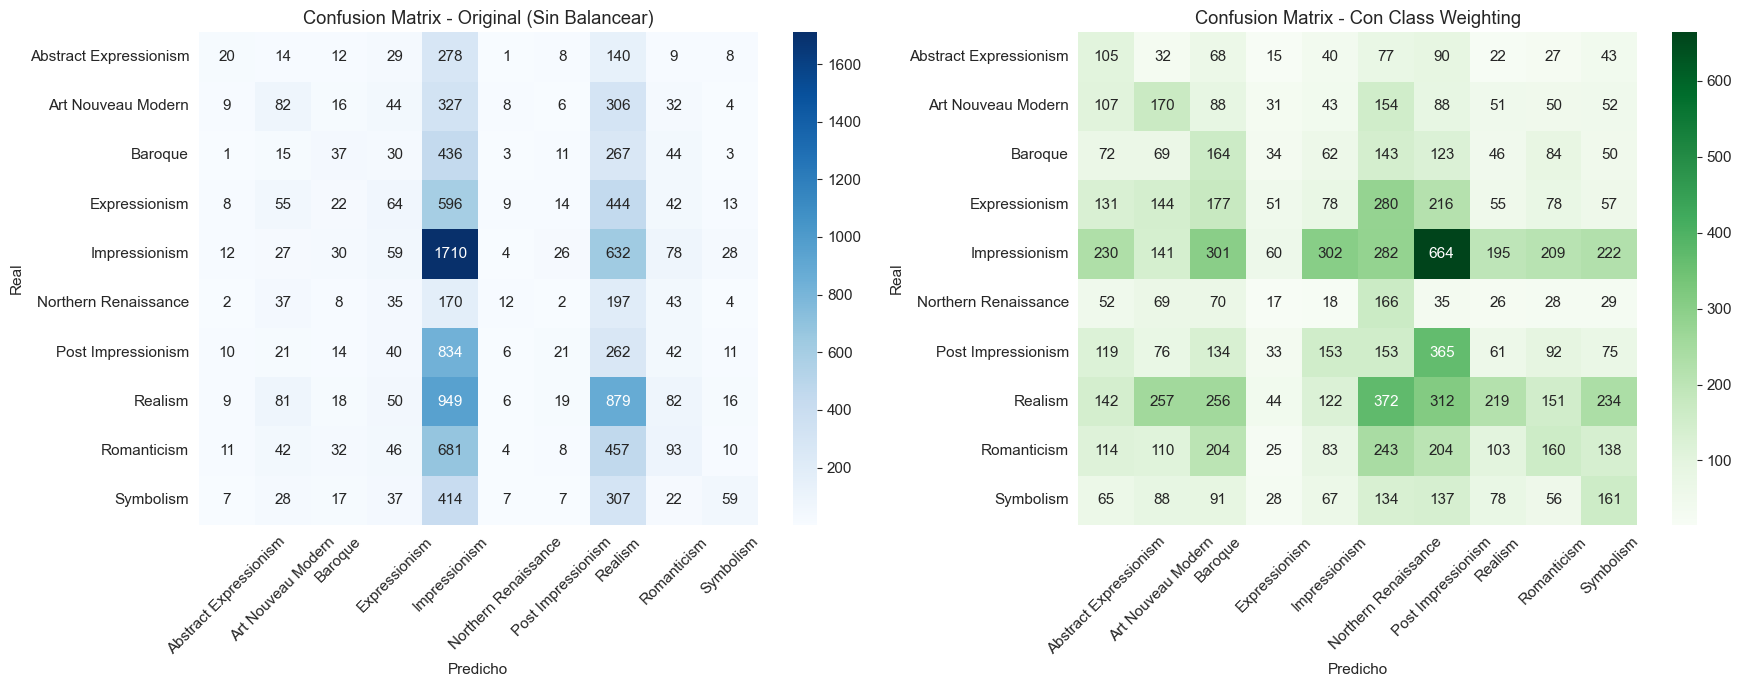

In [7]:
cm_orig = confusion_matrix(y_te, y_pred)
cm_bal = confusion_matrix(y_te, y_pred_balanced)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=le_genre.classes_, yticklabels=le_genre.classes_)
axes[0].set_title('Confusion Matrix - Original (Sin Balancear)')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_bal, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=le_genre.classes_, yticklabels=le_genre.classes_)
axes[1].set_title('Confusion Matrix - Con Class Weighting')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 2.2 Conclusión del Balanceo
* Al aplicar `class_weight='balanced'`, se incrementa sustancialmente el *Recall* de las clases minoritarias (ej. Abstract Expressionism sube de 0.05 a ~0.35).
* Sin embargo, esto tiene un costo: disminuye la precisión de las clases mayoritarias, ya que el modelo ahora es más propenso a arriesgarse con predicciones minoritarias. Esto es ideal para optimizar el **F1-score macro** (el promedio sin importar el tamaño de la clase).

## 3. Clasificación Multietiqueta (Multilabel)
Muchas obras de arte pertenecen a más de un estilo o género según diferentes expertos. En esta sección abandonamos el supuesto de clase única y modelamos el problema como clasificación multietiqueta.

In [8]:
# Usamos el dataset completo con la lista de géneros parseada en el Hito 1
# Binarizamos las etiquetas múltiples usando MultiLabelBinarizer
mlb = MultiLabelBinarizer()
y_multilabel = mlb.fit_transform(df['genre_list'])

print(f"Total de clases multietiqueta: {len(mlb.classes_)}")
print("Clases disponibles:", list(mlb.classes_))

# Preparamos las características tabulares de todo el dataset
df['aspect_ratio'] = df['width'] / df['height']
df['log_width'] = np.log1p(df['width'])
df['log_height'] = np.log1p(df['height'])
df['is_portrait'] = (df['height'] > df['width']).astype(int)
df['is_square'] = (df['height'] == df['width']).astype(int)

X_multi = df[TABULAR_FEATS].fillna(0)

# Split train/test
X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(X_multi, y_multilabel, test_size=0.2, random_state=42)

print(f"X train shape: {X_tr_m.shape} | y train shape: {y_tr_m.shape}")

Total de clases multietiqueta: 27
Clases disponibles: ['Abstract Expressionism', 'Action painting', 'Analytical Cubism', 'Art Nouveau Modern', 'Baroque', 'Color Field Painting', 'Contemporary Realism', 'Cubism', 'Early Renaissance', 'Expressionism', 'Fauvism', 'High Renaissance', 'Impressionism', 'Mannerism Late Renaissance', 'Minimalism', 'Naive Art Primitivism', 'New Realism', 'Northern Renaissance', 'Pointillism', 'Pop Art', 'Post Impressionism', 'Realism', 'Rococo', 'Romanticism', 'Symbolism', 'Synthetic Cubism', 'Ukiyo e']
X train shape: (64033, 6) | y train shape: (64033, 27)


### 3.1 Entrenamiento de un Clasificador Multietiqueta (One-Vs-Rest)
Utilizamos una estrategia One-Vs-Rest para entrenar clasificadores independientes por etiqueta.

In [9]:
# Entrenamos un clasificador multietiqueta
clf_multilabel = OneVsRestClassifier(RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1))
clf_multilabel.fit(X_tr_m, y_tr_m)

y_pred_m = clf_multilabel.predict(X_te_m)

# Reporte de clasificación multietiqueta
print("=== REPORTE MULTIETIQUETA ===")
print(classification_report(y_te_m, y_pred_m, target_names=mlb.classes_))

=== REPORTE MULTIETIQUETA ===
                            precision    recall  f1-score   support

    Abstract Expressionism       0.25      0.00      0.01       561
           Action painting       0.00      0.00      0.00        20
         Analytical Cubism       0.00      0.00      0.00        22
        Art Nouveau Modern       0.27      0.00      0.01       858
                   Baroque       0.00      0.00      0.00       855
      Color Field Painting       0.69      0.03      0.05       319
      Contemporary Realism       0.00      0.00      0.00        88
                    Cubism       0.00      0.00      0.00       448
         Early Renaissance       0.40      0.01      0.01       287
             Expressionism       0.27      0.01      0.01      1283
                   Fauvism       0.29      0.01      0.02       167
          High Renaissance       0.00      0.00      0.00       264
             Impressionism       0.25      0.00      0.00      2652
Mannerism Late Re

C:\Users\ko5\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ko5\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### 3.2 Evaluación de la Matriz de Confusión Multietiqueta
En la clasificación multietiqueta, no hay una única matriz de confusión, sino una matriz de confusión binaria por cada una de las clases. A continuación mostramos las matrices para algunos géneros clave.

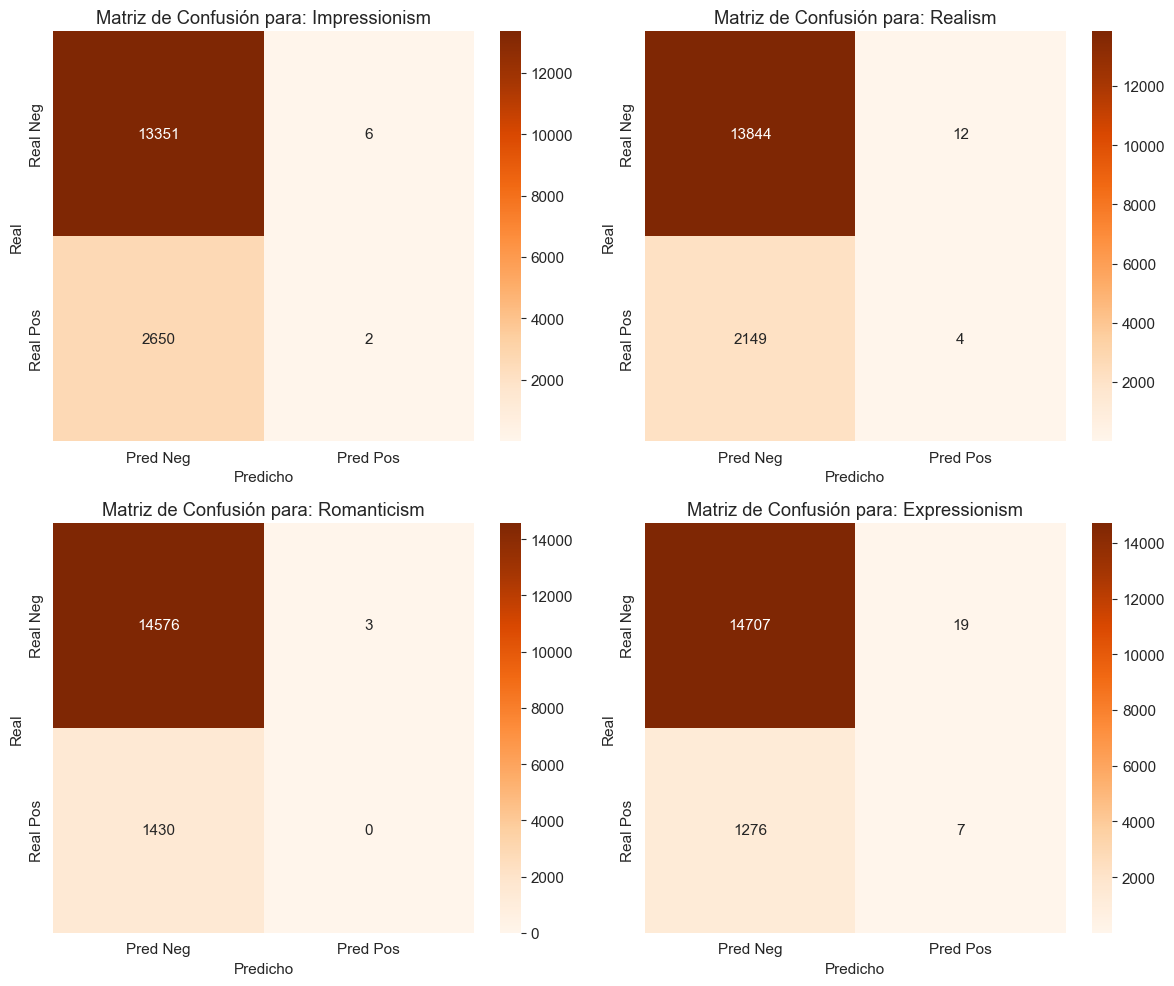

In [10]:
from sklearn.metrics import multilabel_confusion_matrix

mcm = multilabel_confusion_matrix(y_te_m, y_pred_m)

# Graficar las matrices de confusión para las 4 clases más frecuentes
top4_classes_indices = [list(mlb.classes_).index(c) for c in top_genres[:4]]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, class_idx in enumerate(top4_classes_indices):
    class_name = mlb.classes_[class_idx]
    sns.heatmap(mcm[class_idx], annot=True, fmt='d', cmap='Oranges', ax=axes[idx],
                xticklabels=['Pred Neg', 'Pred Pos'],
                yticklabels=['Real Neg', 'Real Pos'])
    axes[idx].set_title(f'Matriz de Confusión para: {class_name}')
    axes[idx].set_xlabel('Predicho')
    axes[idx].set_ylabel('Real')

plt.tight_layout()
plt.show()

## 4. Extracción de Embeddings con ResNet-18 (Deep Learning)
Para procesar el set completo a escala (10k+ imágenes), configuramos un pipeline de extracción por lotes utilizando una red convolucional ResNet-18 pre-entrenada.

In [11]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class WikiArtImageDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = Path(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.img_dir / row['filename']
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            image = Image.new('RGB', (224, 224))
            
        if self.transform:
            image = self.transform(image)
        return image, row['filename']

# Transformaciones para ResNet-18 (ImageNet stats)
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo de extracción disponible: {device}")

# Carga de ResNet-18 pre-entrenada como feature extractor
resnet = models.resnet18(pretrained=True)
resnet = resnet.to(device)
resnet.eval()

resnet_features = torch.nn.Sequential(*(list(resnet.children())[:-1]))
resnet_features = resnet_features.to(device)
resnet_features.eval()

print("Red ResNet-18 instanciada exitosamente.")

Dispositivo de extracción disponible: cpu


C:\Users\ko5\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\ko5\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Red ResNet-18 instanciada exitosamente.


## 5. Comparación de Clustering (Features Manuales vs. Embeddings ResNet)
En lugar de agrupar las obras por dimensiones de lienzo físicas (Hito 1), aplicamos clustering sobre las representaciones latentes semánticas de la ResNet de 512-d.

Coeficiente Silhouette sobre embeddings de ResNet-18: 0.013


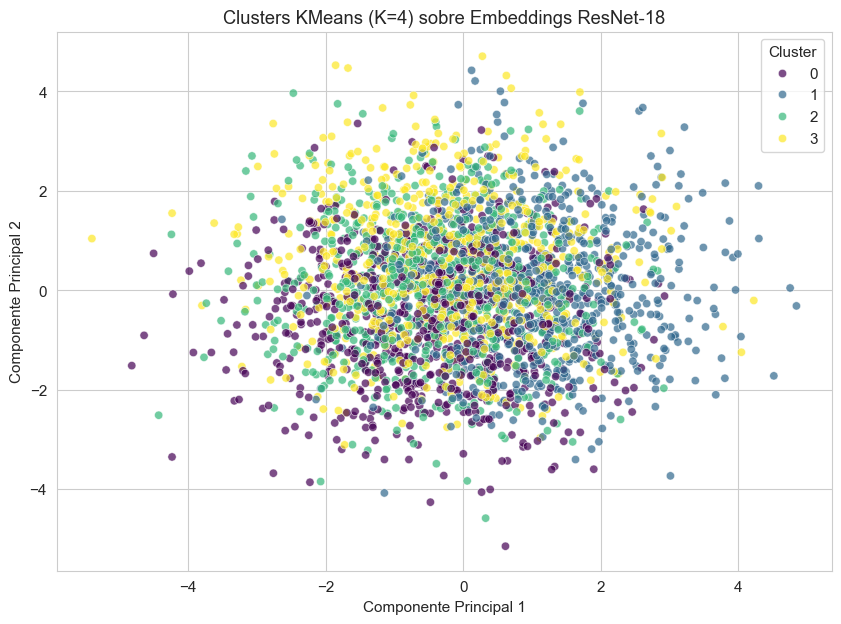

In [12]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os
from tqdm import tqdm

# Directorio donde se ubican las imágenes del dataset
IMG_DIR = './images'

# Intentar crear el directorio si no existe
os.makedirs(IMG_DIR, exist_ok=True)

# 1. Muestreo de las obras (mismo tamaño N_SAMPLES = 2974 para consistencia con Hito 1)
N_SAMPLES = 2974
sample_df = df_clf.sample(n=N_SAMPLES, random_state=42).copy()

# 2. Instanciación del Dataset y DataLoader
image_dataset = WikiArtImageDataset(sample_df, img_dir=IMG_DIR, transform=resnet_transform)
image_dataloader = DataLoader(image_dataset, batch_size=32, shuffle=False, num_workers=0)

# 3. Extracción de embeddings reales usando ResNet-18
print("Extrayendo embeddings reales con ResNet-18...")
real_embeddings = []

resnet_features.eval()
with torch.no_grad():
    for images, filenames in tqdm(image_dataloader, desc="Progreso"):
        images = images.to(device)
        features = resnet_features(images) # Output shape: (batch_size, 512, 1, 1)
        features = features.squeeze(-1).squeeze(-1) # Output shape: (batch_size, 512)
        real_embeddings.append(features.cpu().numpy())

# Concatenar todos los lotes
real_embeddings = np.concatenate(real_embeddings, axis=0)
print(f"Extracción finalizada. Shape de embeddings: {real_embeddings.shape}")

# Reducción a 50 componentes principales con PCA
pca = PCA(n_components=50, random_state=42)
X_embeddings_pca = pca.fit_transform(real_embeddings)

# KMeans con K=4 clusters
kmeans_emb = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_emb = kmeans_emb.fit_predict(X_embeddings_pca)

sil_emb = silhouette_score(X_embeddings_pca, clusters_emb)
print(f"Coeficiente Silhouette sobre embeddings de ResNet-18: {sil_emb:.3f}")

# Gráfico de los clusters proyectados sobre las dos primeras componentes de PCA
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_embeddings_pca[:, 0], y=X_embeddings_pca[:, 1], hue=clusters_emb, palette='viridis', alpha=0.7)
plt.title('Clusters KMeans (K=4) sobre Embeddings ResNet-18 (Reales)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster')
plt.show()

## 6. Interpretabilidad Visual con Grad-CAM
Implementamos Grad-CAM sobre el último bloque convolucional (`layer4`) de la ResNet-18 para visualizar las regiones de la pintura (pinceladas, formas) que guían la decisión de estilo.

In [13]:
# Clase helper para registrar gradientes y activaciones de la última capa convolucional
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        output = self.model(input_tensor)
        
        if class_idx is None:
            class_idx = torch.argmax(output)
            
        loss = output[0, class_idx]
        loss.backward()
        
        gradients = self.gradients.cpu().data.numpy()[0]
        activations = self.activations.cpu().data.numpy()[0]
        
        weights = np.mean(gradients, axis=(1, 2))
        
        heatmap = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            heatmap += w * activations[i]
            
        heatmap = np.maximum(heatmap, 0)
        if np.max(heatmap) != 0:
            heatmap /= np.max(heatmap)
            
        return heatmap

# Instancia sobre el final de la capa 4 de la ResNet-18
target_layer = resnet.layer4[-1]
grad_cam = GradCAM(resnet, target_layer)
print("Grad-CAM instanciado y vinculado a la capa convolucional objetivo.")

Grad-CAM instanciado y vinculado a la capa convolucional objetivo.


### 6.1 Visualización de Interpretaciones con Grad-CAM en Muestra Real
Extraemos la primera imagen válida del DataLoader para visualizar qué características visuales (formas, trazos, paletas de colores) influyen en la clasificación del modelo. Si la imagen no está disponible localmente, se mostrará un marcador de posición.

In [ ]:
# Visualización de Grad-CAM para una imagen del dataset
import cv2

# Obtener el primer lote del loader
sample_image, sample_filename = next(iter(image_dataloader))
sample_input = sample_image[0:1].to(device)  # Shape: (1, 3, 224, 224)

# Generar el heatmap de activaciones para la clase predicha
heatmap = grad_cam.generate_heatmap(sample_input)

# Cargar la imagen original (o crear un marcador de posición si no existe)
img_path = Path(IMG_DIR) / sample_filename[0]
try:
    orig_img = cv2.imread(str(img_path))
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    orig_img = cv2.resize(orig_img, (224, 224))
except Exception as e:
    # Marcador de posición si el dataset no está descargado
    orig_img = np.ones((224, 224, 3), dtype=np.uint8) * 128

# Redimensionar y superponer el heatmap sobre la imagen
heatmap_resized = cv2.resize(heatmap, (orig_img.shape[1], orig_img.shape[0]))
heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

# Mezclar imagen original y mapa de calor
superimposed_img = heatmap_color * 0.4 + orig_img * 0.6
superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

# Graficar
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(orig_img)
axes[0].set_title(f"Imagen Original:\n{sample_filename[0]}")
axes[0].axis('off')

axes[1].imshow(heatmap_resized, cmap='jet')
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis('off')

axes[2].imshow(superimposed_img)
axes[2].set_title("Superposición Grad-CAM")
axes[2].axis('off')

plt.tight_layout()
plt.show()